In [1]:
# Cell 1: Imports
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## Load and inspect the dataset
This step loads the UNSW-NB15 CSV file and gives a first look at size, sample rows, and column data types.

In [2]:
# Cell 2: Load CSV and inspect basic structure
csv_path = Path("../data/UNSW_NB15.csv")  # Update to your local file path
df = pd.read_csv(csv_path)

print("Dataset shape:", df.shape)
display(df.head())
display(df.dtypes)

Dataset shape: (500, 46)


,id,attack_cat,srcip,dstip,f1,f2,f3,f4,f5,f6,...,f33,f34,f35,f36,cat1,cat2,cat3,cat4,cat5,label
0,0,DoS,10.0.0.1,192.168.0.1,1.779982,3.878622,3.578795,3.131913,2.193235,3.968524,...,2.709220,3.255775,1.257221,0.960654,http,udp,tcp,http,icmp,0
1,1,Recon,10.0.1.2,192.168.1.4,1.274529,3.394416,1.675024,2.388218,3.648356,3.692244,...,3.926637,3.526948,4.232377,1.826520,icmp,tcp,udp,dns,tcp,1
2,2,Normal,10.0.2.3,192.168.2.7,2.174378,2.269403,2.865342,3.644966,1.222549,1.635026,...,3.467879,2.178511,3.426827,4.588661,tcp,icmp,icmp,dns,dns,0
3,3,DoS,10.0.3.4,192.168.3.10,4.171182,4.853329,1.395130,2.143732,3.424948,2.405986,...,1.278791,3.062645,3.132524,2.643112,dns,udp,tcp,dns,tcp,1
4,4,DoS,10.0.4.5,192.168.4.13,3.025411,1.583232,2.012376,4.202370,7.479417,2.665379,...,1.378627,2.802948,3.364889,4.862197,dns,dns,icmp,http,dns,0


id              int64
attack_cat     object
srcip          object
dstip          object
f1            float64
f2            float64
f3            float64
f4            float64
f5            float64
f6            float64
f7            float64
f8            float64
f9            float64
f10           float64
f11           float64
f12           float64
f13           float64
f14           float64
f15           float64
f16           float64
f17           float64
f18           float64
f19           float64
f20           float64
f21           float64
f22           float64
f23           float64
f24           float64
f25           float64
f26           float64
f27           float64
f28           float64
f29           float64
f30           float64
f31           float64
f32           float64
f33           float64
f34           float64
f35           float64
f36           float64
cat1           object
cat2           object
cat3           object
cat4           object
cat5           object
label     

## Missing value analysis
This section checks null counts per column and visualizes missingness to identify cleaning needs.

id            0
f31           0
f22           0
f23           0
f24           0
f25           0
f26           0
f27           0
f28           0
f29           0
f30           0
f32           0
attack_cat    0
f33           0
f34           0
f35           0
f36           0
cat1          0
cat2          0
cat3          0
cat4          0
cat5          0
f21           0
f20           0
f19           0
f18           0
srcip         0
dstip         0
f1            0
f2            0
f3            0
f4            0
f5            0
f6            0
f7            0
f8            0
f9            0
f10           0
f11           0
f12           0
f13           0
f14           0
f15           0
f16           0
f17           0
label         0
dtype: int64

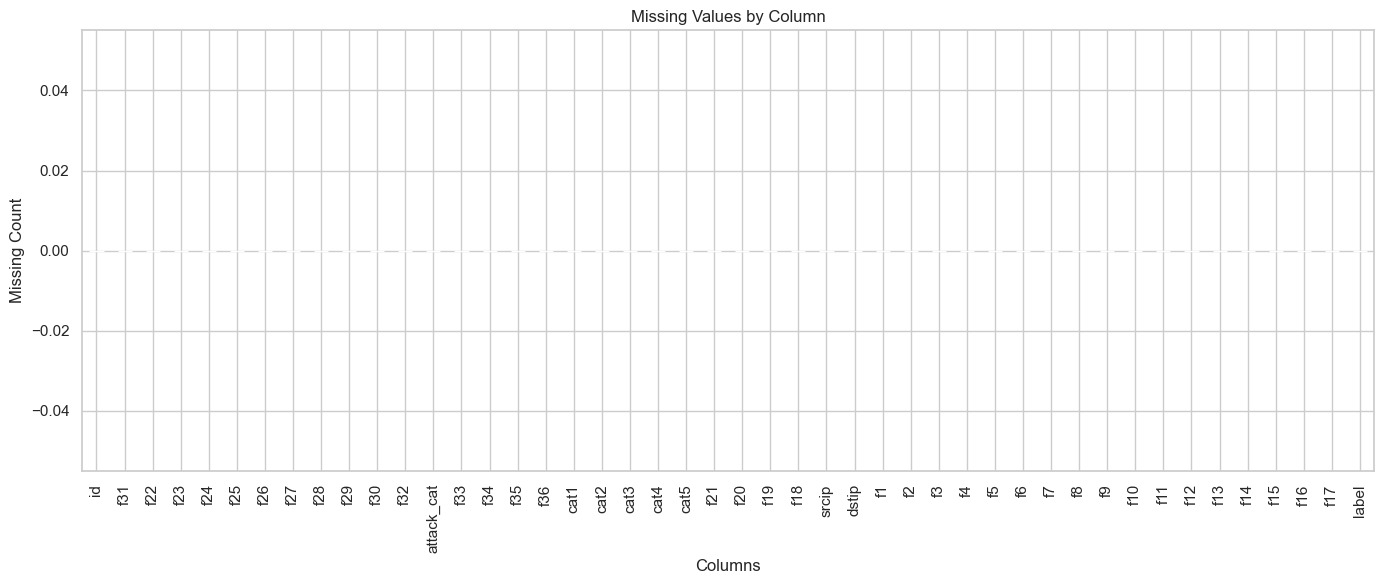

In [4]:
# Cell 3: Missing values summary and bar chart

missing_counts = df.isnull().sum().sort_values(ascending=False)

display(missing_counts)



plt.figure(figsize=(14, 6))

missing_counts.plot(kind="bar", color="tomato")

plt.title("Missing Values by Column")

plt.xlabel("Columns")

plt.ylabel("Missing Count")

plt.tight_layout()

plt.show()

## Class balance check
Here we inspect the target class distribution for normal vs attack labels to understand imbalance.

label
0    250
1    250
Name: count, dtype: int64

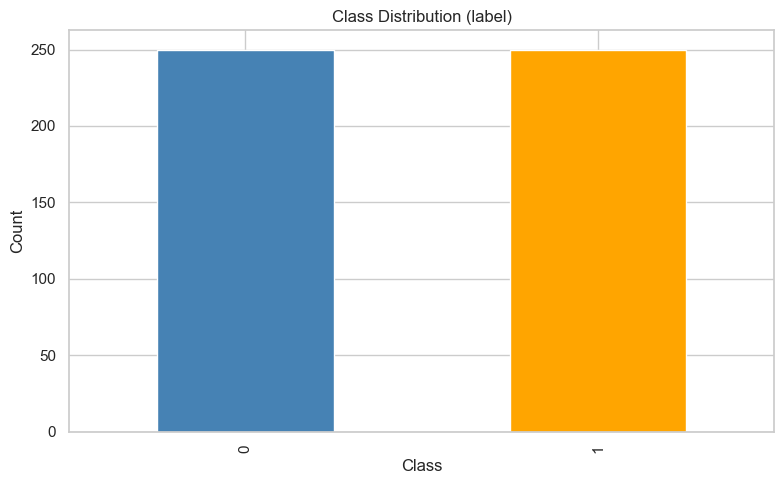

In [5]:
# Cell 4: Class distribution for label
if "label" not in df.columns:
    raise ValueError("Column 'label' not found in dataset.")

label_counts = df["label"].value_counts()
display(label_counts)

plt.figure(figsize=(8, 5))
label_counts.plot(kind="bar", color=["steelblue", "orange"])
plt.title("Class Distribution (label)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Feature distribution overview
This plots histograms for the first 10 numeric features to quickly inspect spread and skew.

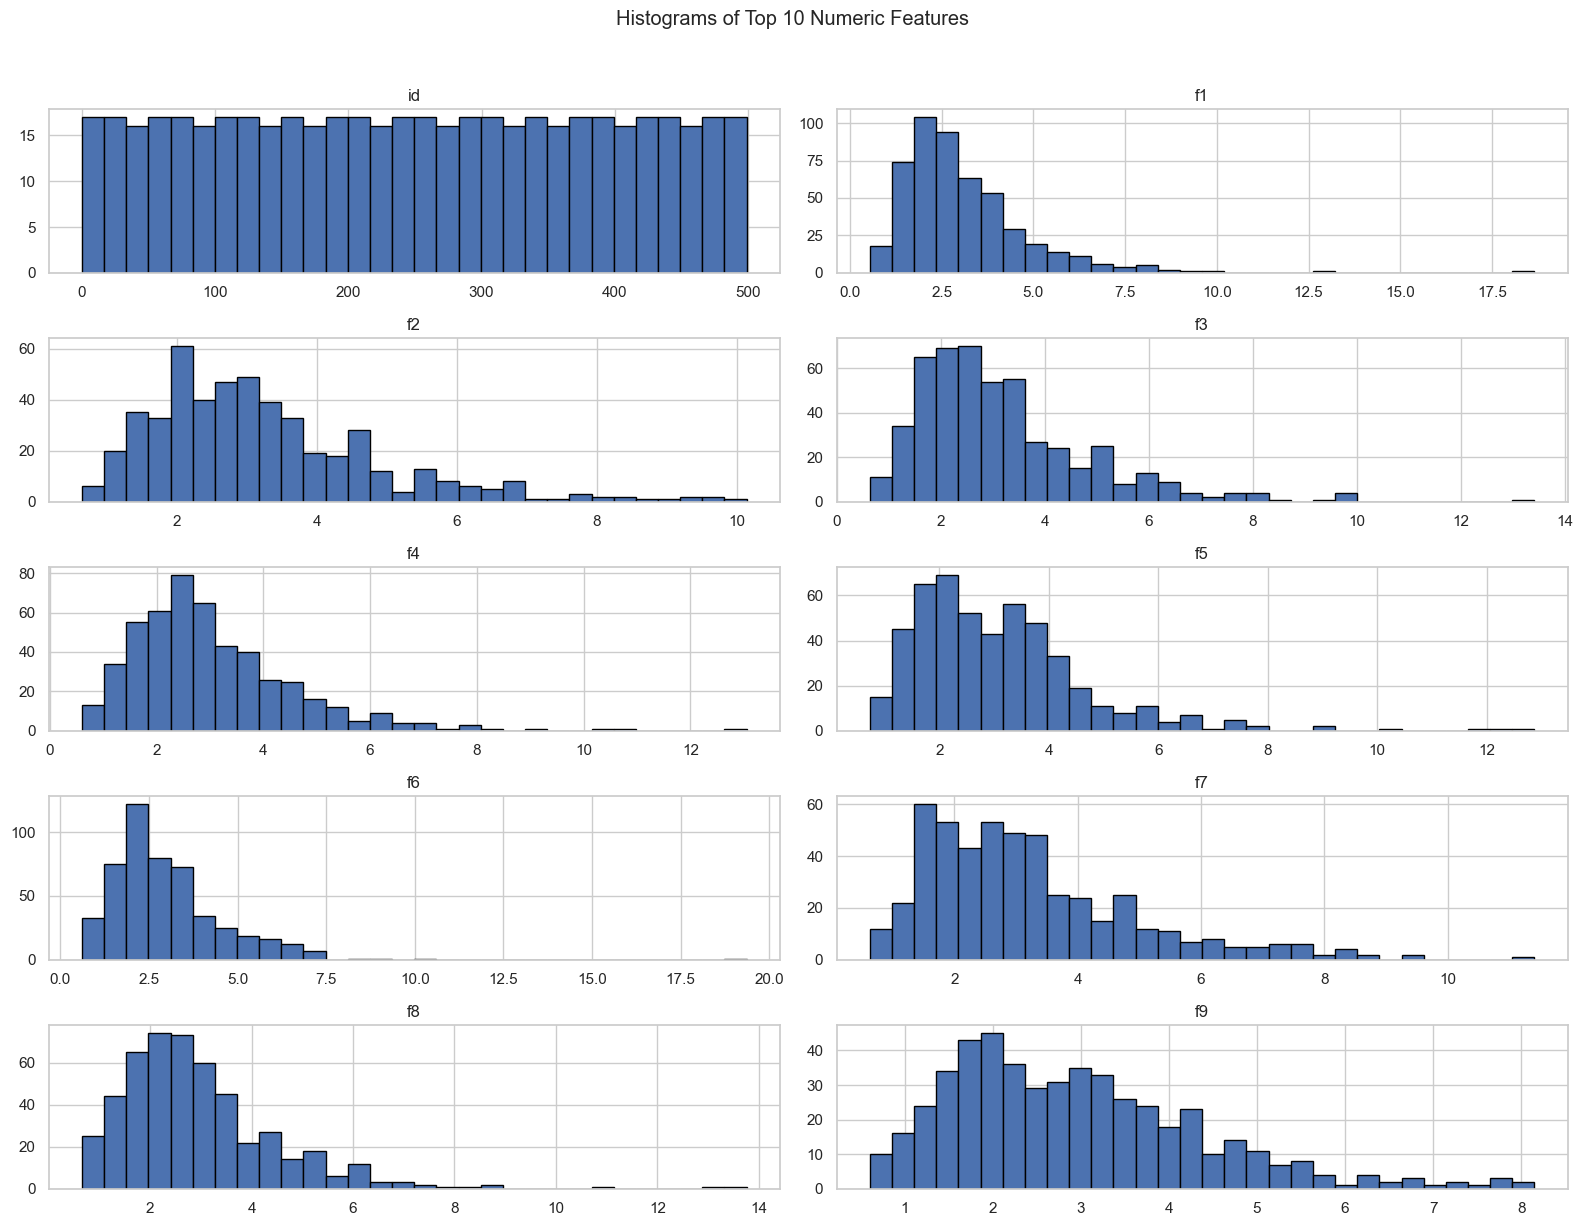

In [6]:
# Cell 5: Histograms for top 10 numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
top_10_numeric = numeric_cols[:10]

if not top_10_numeric:
    raise ValueError("No numeric columns available for histogram plotting.")

df[top_10_numeric].hist(bins=30, figsize=(16, 12), layout=(5, 2), edgecolor="black")
plt.suptitle("Histograms of Top 10 Numeric Features", y=1.02)
plt.tight_layout()
plt.show()

## Correlation structure
A heatmap of numeric-feature correlations helps reveal redundant variables and feature relationships.

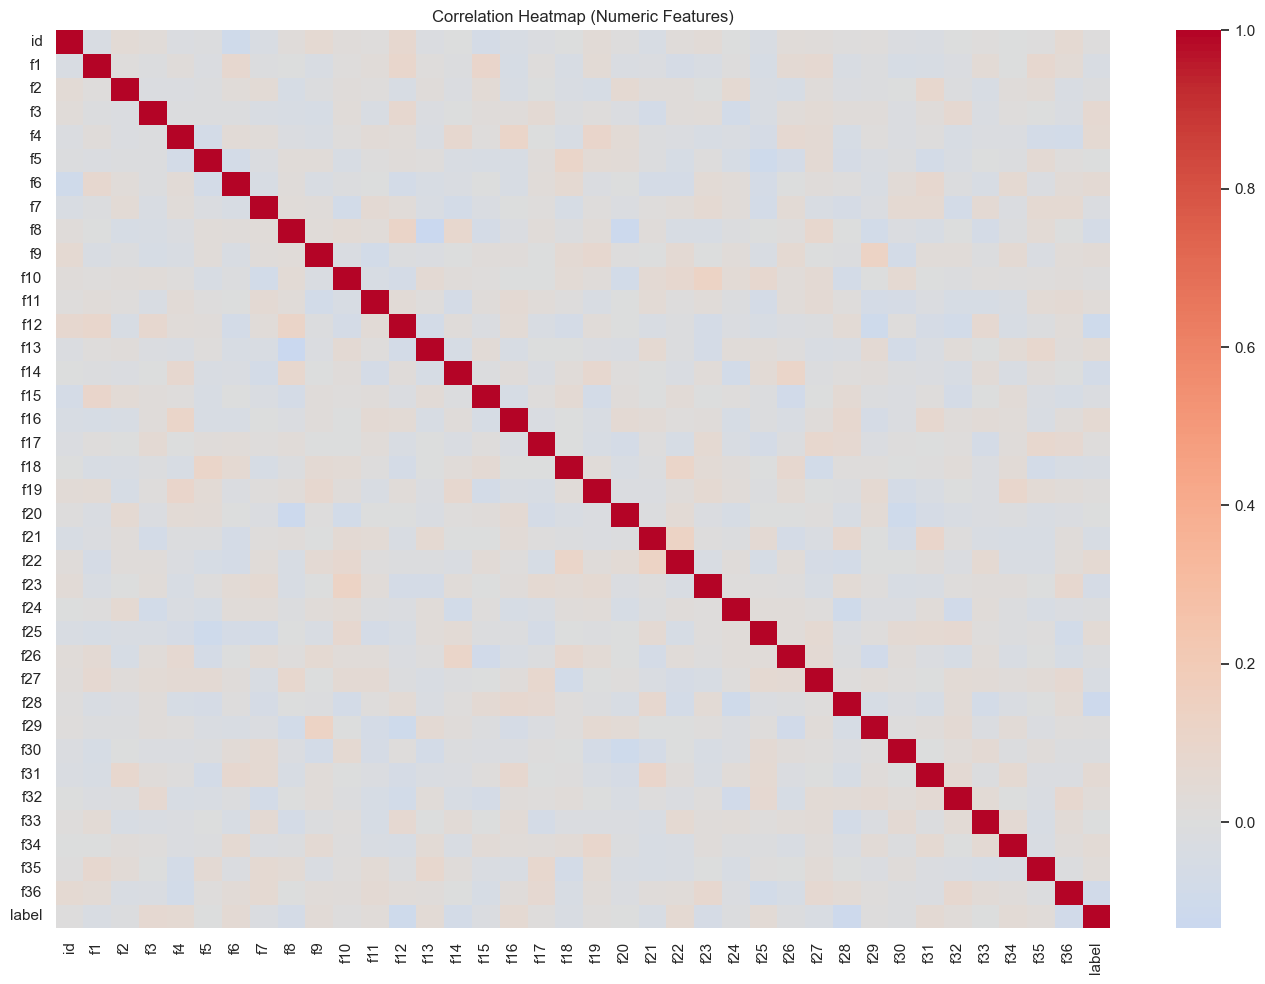

In [8]:
# Cell 6: Correlation heatmap for numeric features
corr = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, square=False)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()

## Example traffic sequence visualization
This plots one 50-timestep sample using the first five numeric features as parallel time series.

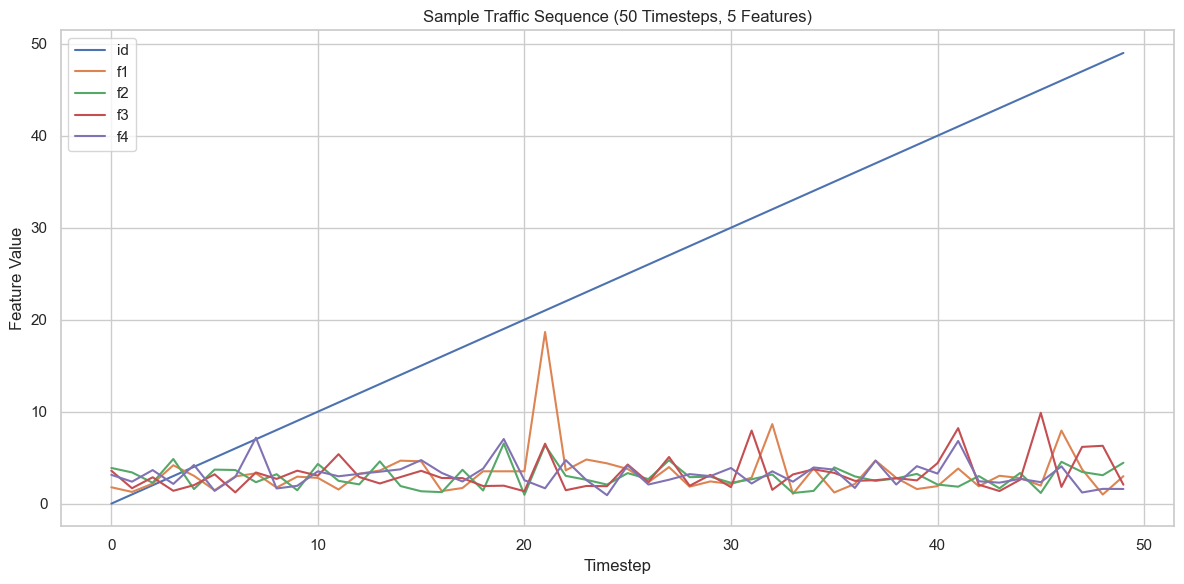

In [11]:
# Cell 7: Plot one sample traffic sequence (50 timesteps, first 5 features)
sequence_len = 50
numeric_df = df.select_dtypes(include=[np.number])
feature_cols = [col for col in numeric_df.columns if col != "label"][:5]

if len(feature_cols) < 5:
    raise ValueError("Need at least 5 numeric feature columns to plot the sequence.")
if len(numeric_df) < sequence_len:
    raise ValueError("Dataset has fewer than 50 rows; cannot create 50-timestep sequence.")

sample_sequence = numeric_df[feature_cols].iloc[:sequence_len].reset_index(drop=True)

plt.figure(figsize=(12, 6))
for feature_name in feature_cols:
    plt.plot(sample_sequence.index, sample_sequence[feature_name], label=feature_name)

plt.title("Sample Traffic Sequence (50 Timesteps, 5 Features)")
plt.xlabel("Timestep")
plt.ylabel("Feature Value")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

## Run preprocessing pipeline and summarize outputs
This executes the project preprocessing pipeline and prints artifact paths, tensor shapes, and class distributions.

In [12]:
# Cell 8: Summary statistics after preprocessing pipeline
import sys

project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from backend.data.preprocess import preprocess_pipeline

processed_output_dir = project_root / "backend" / "data" / "processed"
summary = preprocess_pipeline(
    csv_path=str(csv_path),
    output_dir=str(processed_output_dir),
    seq_len=50,
)

print("Artifacts:")
for key, value in summary["artifacts"].items():
    print(f"  {key}: {value}")

print("\nShapes:")
for key, value in summary["shapes"].items():
    print(f"  {key}: {value}")

print("\nClass Distribution:")
for split_name, dist in summary["class_distribution"].items():
    print(f"  {split_name}: {dist}")

Artifacts:
  scaler: C:\Users\SJB\Downloads\geniot-optimizer\backend\data\processed\scaler.pkl
  X_train: C:\Users\SJB\Downloads\geniot-optimizer\backend\data\processed\X_train.npy
  X_val: C:\Users\SJB\Downloads\geniot-optimizer\backend\data\processed\X_val.npy
  X_test: C:\Users\SJB\Downloads\geniot-optimizer\backend\data\processed\X_test.npy
  y_train: C:\Users\SJB\Downloads\geniot-optimizer\backend\data\processed\y_train.npy
  y_val: C:\Users\SJB\Downloads\geniot-optimizer\backend\data\processed\y_val.npy
  y_test: C:\Users\SJB\Downloads\geniot-optimizer\backend\data\processed\y_test.npy

Shapes:
  raw_after_cleaning: [500, 42]
  X_train_scaled: [350, 41]
  X_val_scaled: [75, 41]
  X_test_scaled: [75, 41]
  X_train_windows: [301, 50, 41]
  X_val_windows: [26, 50, 41]
  X_test_windows: [26, 50, 41]
  y_train: [301]
  y_val: [26]
  y_test: [26]

Class Distribution:
  train: {'0': 153, '1': 148}
  val: {'0': 13, '1': 13}
  test: {'0': 14, '1': 12}
